In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Configurações para qualidade de publicação (alta resolução)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif' # Padrão acadêmico

DIR_IBGE = Path("../dados/brutos/ibge")
DIR_PROC = Path("../dados/processados/ibge")
DIR_OVERTURE = Path("../dados/brutos/overture")

In [34]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Estilo compartilhado (alinhado ao NB 02.1)
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 10,
    'axes.titlesize': 10, 'axes.labelsize': 9,
    'xtick.labelsize': 6, 'ytick.labelsize': 6, 'legend.fontsize': 7,
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F8F8',
    'axes.grid': True, 'grid.alpha': 0.4, 'grid.linestyle': '--',
})

def barra_escala(ax, comprimento_m=5000, rotulo='5 km', frac_x=0.02, frac_y=0.01):
    """Barra de escala em unidades métricas (UTM). Chamar após os .plot()."""
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    xi = x0 + (x1 - x0) * frac_x; yi = y0 + (y1 - y0) * frac_y
    h = (y1 - y0) * 0.006
    ax.add_patch(Rectangle((xi, yi), comprimento_m/2, h, fc='black', ec='black', zorder=10))
    ax.add_patch(Rectangle((xi+comprimento_m/2, yi), comprimento_m/2, h, fc='white', ec='black', zorder=10))
    ax.text(xi, yi + h*2.2, '0', ha='center', fontsize=7, zorder=10)
    ax.text(xi + comprimento_m, yi + h*2.2, rotulo, ha='center', fontsize=7, zorder=10)

def seta_norte(ax, frac_x=0.94, frac_y=0.88):
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    xn = x0 + (x1 - x0) * frac_x; yn = y0 + (y1 - y0) * frac_y
    d = (y1 - y0) * 0.05
    ax.annotate('', xy=(xn, yn + d), xytext=(xn, yn),
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.6), zorder=10)
    ax.text(xn, yn + d*1.2, 'N', ha='center', va='bottom', fontsize=11, fontweight='bold', zorder=10)

def moldura_mapa(ax, titulo, fonte):
    ax.set_title(titulo, pad=12)
    ax.set_xlabel('Este (m) — SIRGAS 2000 / UTM 23S')
    ax.set_ylabel('Norte (m) — SIRGAS 2000 / UTM 23S')
    ax.tick_params(labelsize=7)
    ax.figure.text(0.5, 0.005, f'Fonte: {fonte}', ha='center', fontsize=7,
                   style='italic', color='#555555')

## Figura X – Delimitação da área de estudo

Este código sobrepõe o limite municipal, o buffer de 5 km e a zona urbana, criando a hierarquia visual necessária para explicar o recorte espacial.

In [11]:
url_pi = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2025/UFs/PI/PI_Municipios_2025.zip"
gdf_pi_uf = gpd.read_file(f"zip+{url_pi}").dissolve()[['geometry']].to_crs(31983)

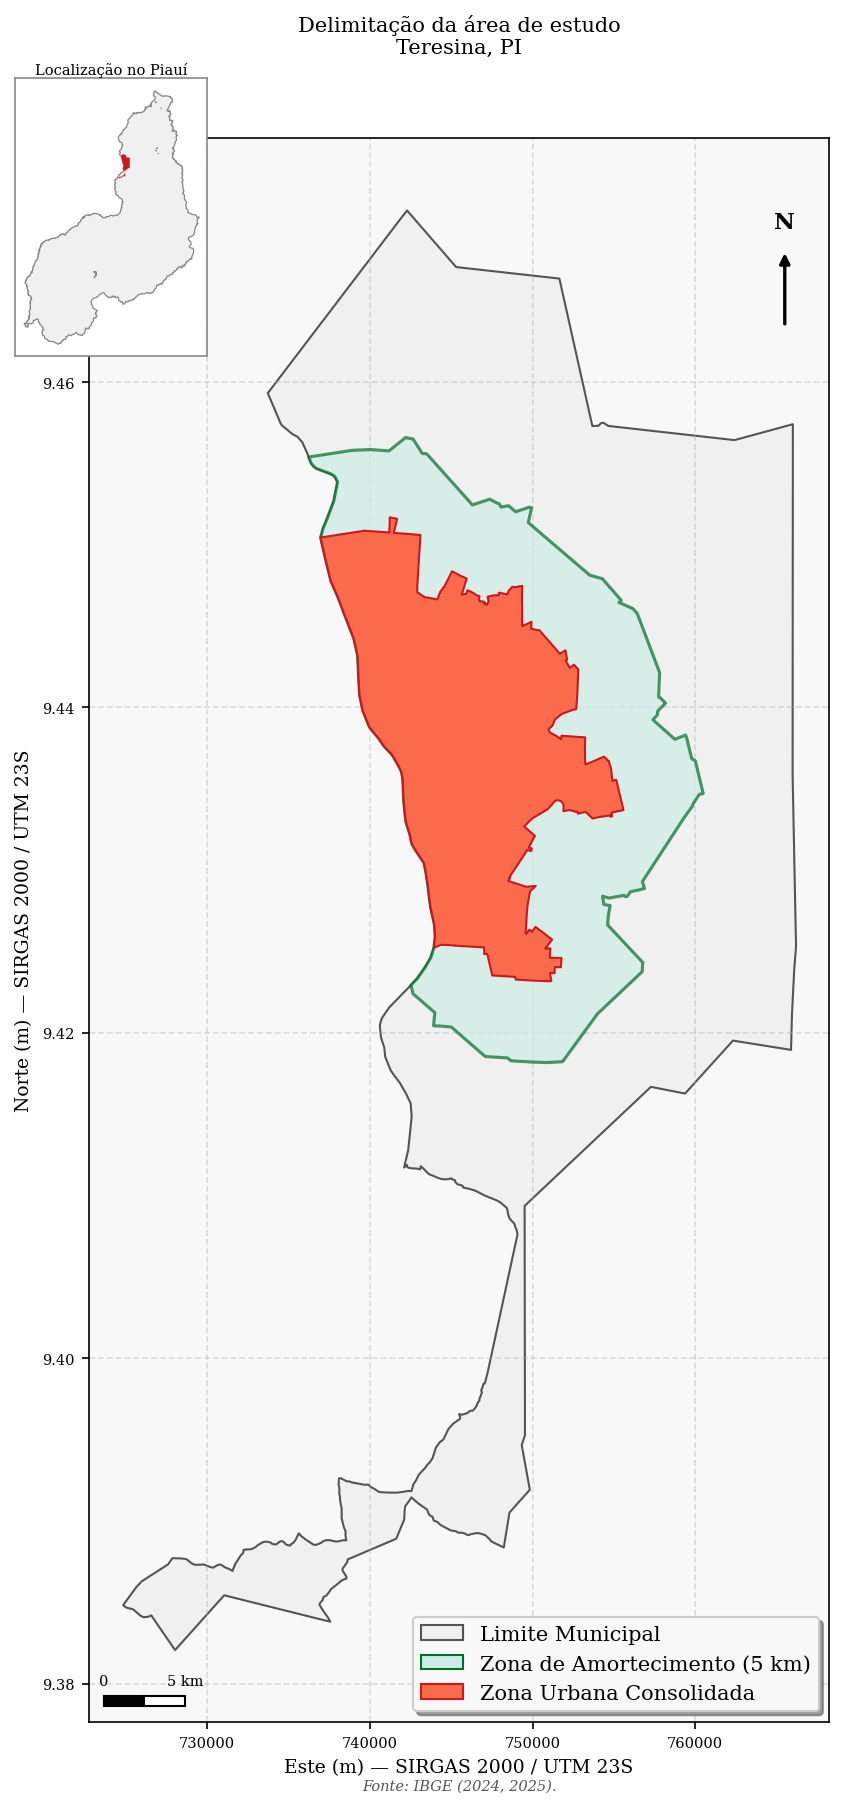

In [25]:
# 1. Carregando os dados
gdf_teresina = gpd.read_parquet(DIR_IBGE / "teresina.parquet")
gdf_buffer = gpd.read_parquet(DIR_IBGE / "teresina_zonaUrbanaClip_utm.parquet")
gdf_zu = gpd.read_parquet(DIR_IBGE / "teresina_zonaUrbana_utm.parquet")

# 2. Configurando a figura
fig, ax = plt.subplots(figsize=(10, 12))
ax.set_title("Delimitação da Área de Estudo - Teresina (PI)", fontsize=12, pad=15)

# 3. Plotagem em camadas (zorder define quem fica por cima)
gdf_teresina.plot(ax=ax, color='#f0f0f0', edgecolor='#555555', linewidth=1, zorder=1)
gdf_buffer.plot(ax=ax, color='#ccece6', edgecolor='#006d2c', linewidth=1.5, alpha=0.7, zorder=2)
gdf_zu.plot(ax=ax, color='#fb6a4a', edgecolor='#cb181d', linewidth=1, zorder=3)

# 4. Criação da Legenda Manual
legenda_municipio = mpatches.Patch(color='#f0f0f0', ec='#555555', label='Limite Municipal')
legenda_buffer = mpatches.Patch(color='#ccece6', ec='#006d2c', label='Zona de Amortecimento (5 km)')
legenda_zu = mpatches.Patch(color='#fb6a4a', ec='#cb181d', label='Zona Urbana Consolidada')

ax.legend(handles=[legenda_municipio, legenda_buffer, legenda_zu], 
          loc='lower right', fontsize=10, frameon=True, shadow=True)

# 5. Ocultar os eixos de coordenadas (limpeza visual)
moldura_mapa(ax, 'Delimitação da área de estudo\nTeresina, PI', 'IBGE (2024, 2025).')
barra_escala(ax, comprimento_m=5000, rotulo='5 km')
seta_norte(ax)

# --- Mapa de localização: Teresina dentro do Piauí (eixo secundário) ---
# gdf_pi_uf = gpd.read_parquet(DIR_IBGE / "piaui_uf.parquet")

# Cria o eixo secundário no canto superior esquerdo (coordenadas em fração do eixo principal)
axins = ax.inset_axes([-0.10, 0.82, 0.26, 0.26])

gdf_pi_uf.plot(ax=axins, color='#f0f0f0', edgecolor='#888888', linewidth=0.6)
gdf_teresina.plot(ax=axins, color='#cb181d', edgecolor='none')   # município destacado

axins.set_title('Localização no Piauí', fontsize=7, pad=2)
axins.set_xticks([]); axins.set_yticks([])
axins.grid(False)                 # remove a grade herdada do estilo global
axins.set_facecolor('white')
for borda in axins.spines.values():
    borda.set_edgecolor('#888888'); borda.set_linewidth(0.8)

plt.tight_layout()
plt.savefig("../outputs/figuras/1.1_figura_area_estudo.png", bbox_inches='tight')
plt.show()

## Figura Y – Distribuição espacial da demanda

Aqui, utilizamos a variável V06006_renda (Rendimento Nominal Mediano) estruturada no seu pipeline ETL para demonstrar a heterogeneidade socioeconômica na malha urbana.

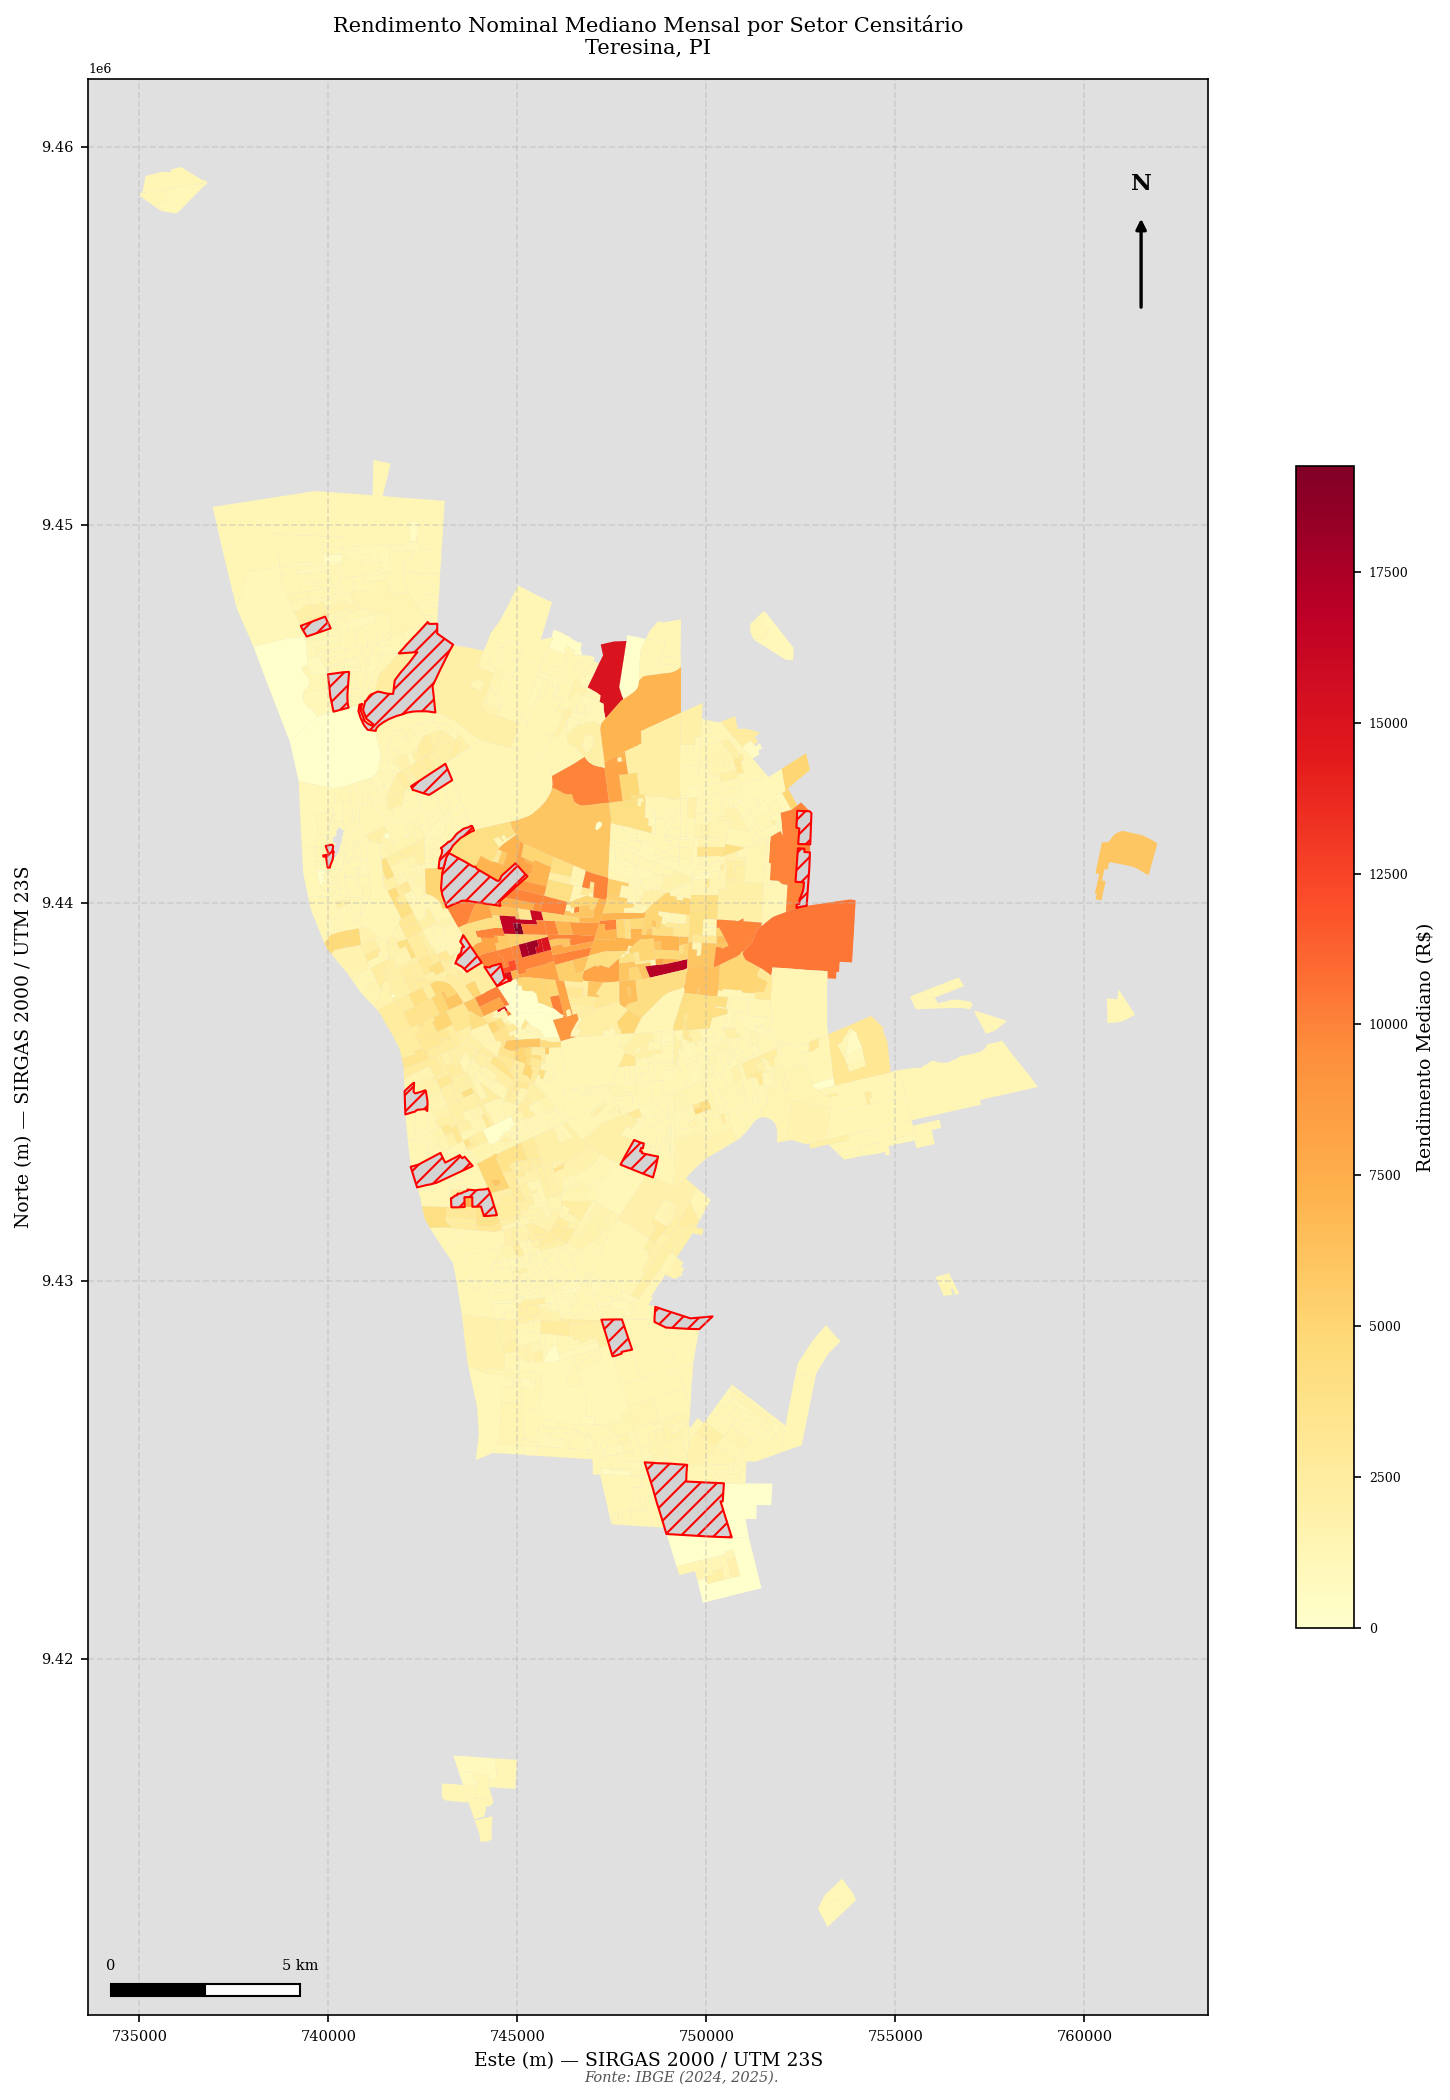

In [26]:
# 1. Carregando a malha de setores censitários enriquecida
gdf_setores = gpd.read_parquet(DIR_PROC / "teresina_setoresCensitarios_DadosCompletos.parquet")

# 2. Configurando a figura
fig, ax = plt.subplots(figsize=(12, 14))
ax.set_title("Rendimento Nominal Mediano Mensal por Setor Censitário", fontsize=14, pad=15)
ax.set_facecolor('#e0e0e0') # Fundo levemente cinza para destacar vazios urbanos

# 3. Plotagem do Mapa Coroplético (Mapa de Calor)
# O cmap 'YlOrRd' (Yellow-Orange-Red) é excelente para representar gradação de valores
gdf_setores.plot(
    column='V06006_renda', 
    ax=ax, 
    cmap='YlOrRd', 
    edgecolor='none', # Remove a borda dos setores para não poluir
    legend=True,
    legend_kwds={
        'label': "Rendimento Mediano (R$)",
        'orientation': "vertical",
        'shrink': 0.6 # Tamanho da barra lateral
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "red",
        "hatch": "///",
        "label": "Dados não disponíveis/Censurados"
    }
)

# 5. Ocultar os eixos de coordenadas (limpeza visual)
moldura_mapa(ax, 'Rendimento Nominal Mediano Mensal por Setor Censitário\nTeresina, PI', 'IBGE (2024, 2025).')
barra_escala(ax, comprimento_m=5000, rotulo='5 km')
seta_norte(ax)

plt.tight_layout()
plt.savefig("../outputs/figuras/1.2_figura_demanda_renda.png", bbox_inches='tight')
plt.show()

## Figura Z – Detalhamento da infraestrutura (Overture Maps)

Como plotar as dezenas de milhares de arestas e edificações de uma vez só geraria um "borrão" visual ininteligível, o segredo deste código é criar um recorte aproximado (zoom) em um ponto central para ilustrar a densidade topológica da rede.

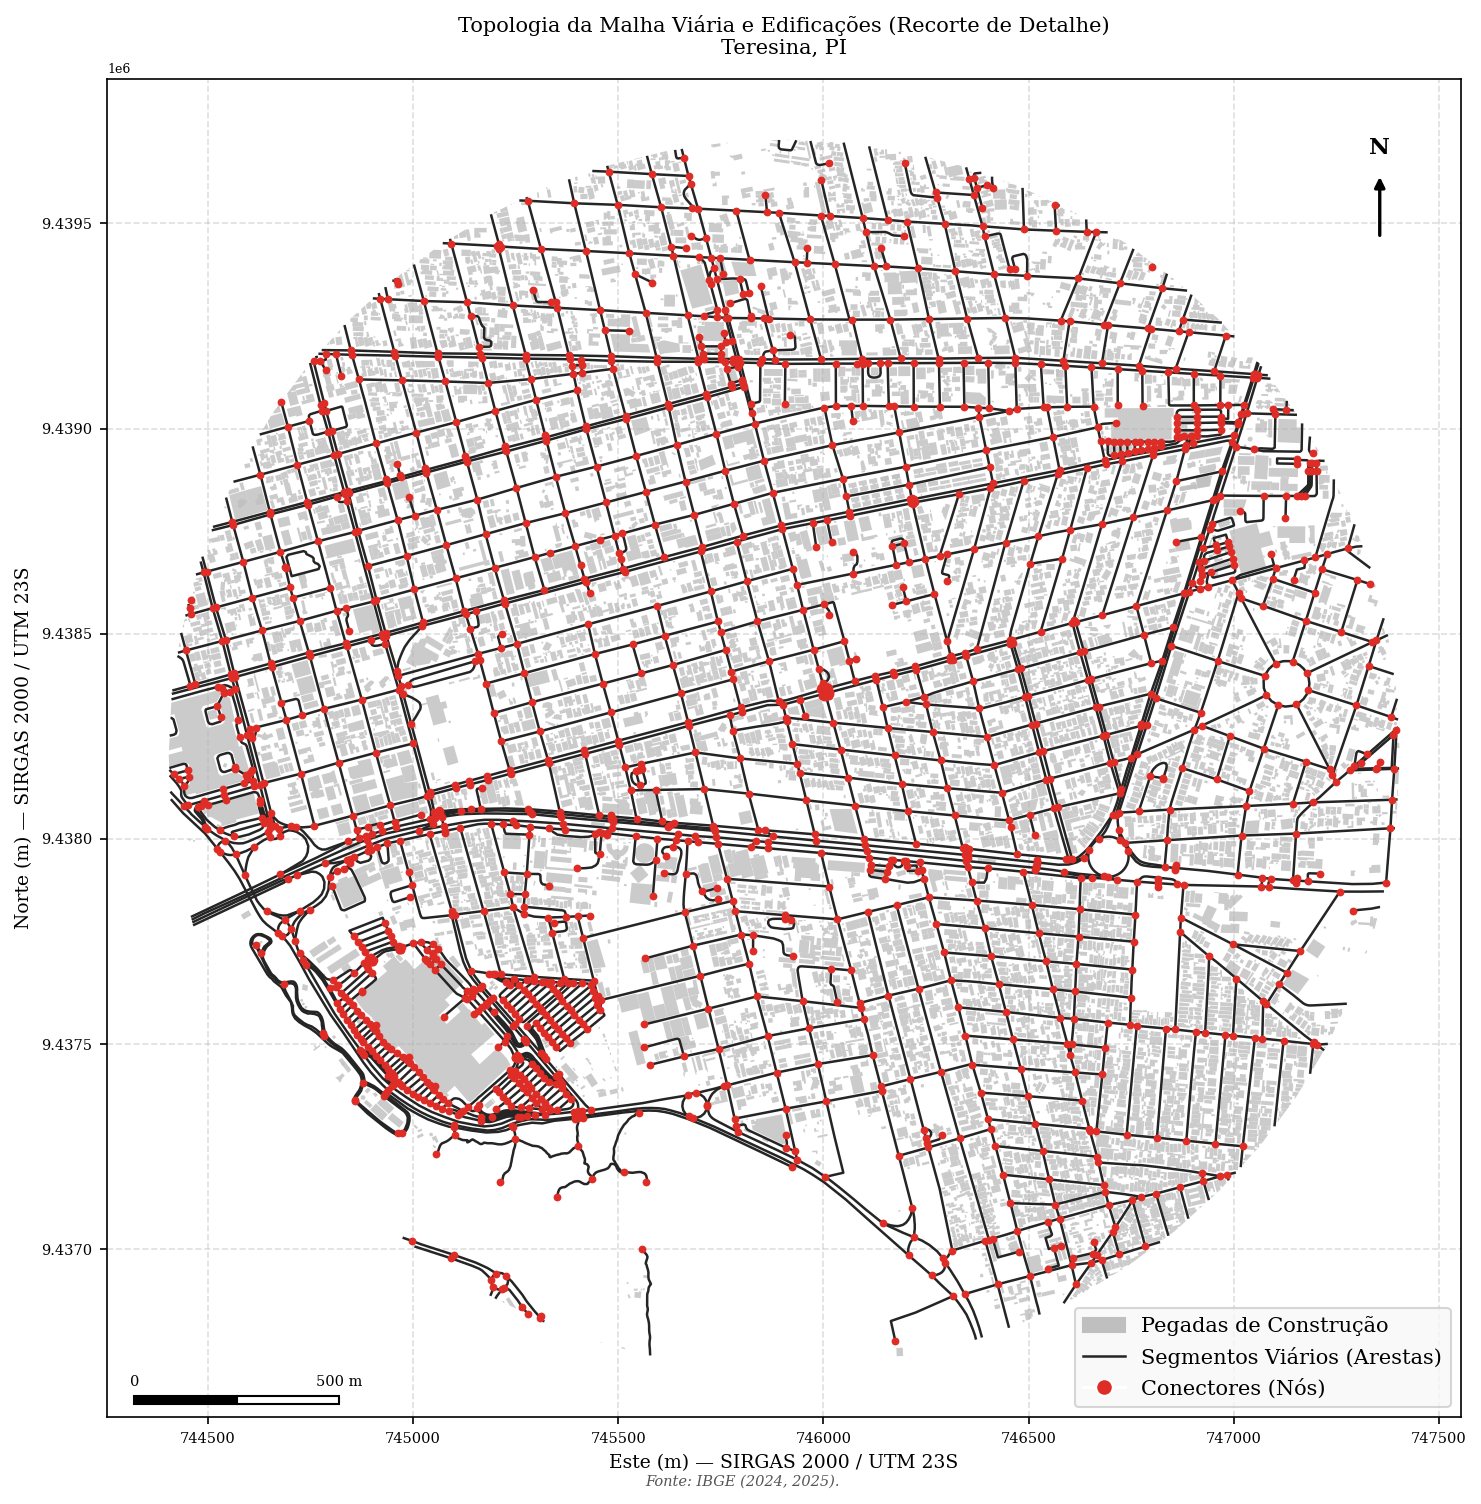

In [35]:
# 1. Carregando as camadas de infraestrutura
gdf_segmentos = gpd.read_parquet(DIR_OVERTURE / "zonaUrbanaReal_5km_segmentos.parquet")
gdf_conectores = gpd.read_parquet(DIR_OVERTURE / "zonaUrbanaReal_5km_conectores.parquet")
gdf_buildings = gpd.read_file(DIR_OVERTURE / "teresina_building_utm.geojson")

# 2. Criando um Bounding Box para o Zoom (raio de 1.5 km no centroide da zona urbana)
# Carrega a zona urbana para achar o "meio" dela
gdf_zu = gpd.read_parquet(DIR_IBGE / "teresina_zonaUrbana_utm.parquet")
ponto_central = gdf_zu.geometry.centroid.iloc[0]
area_zoom = ponto_central.buffer(1500) # Buffer de 1.5 km

# 3. Recortando (Clip) os dados pesados apenas para a área de zoom
gdf_seg_zoom = gpd.clip(gdf_segmentos, area_zoom)
gdf_con_zoom = gpd.clip(gdf_conectores, area_zoom)
gdf_bld_zoom = gpd.clip(gdf_buildings, area_zoom)

# 4. Configurando a figura
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_title("Topologia da Malha Viária e Edificações (Recorte de Detalhe)", fontsize=12, pad=15)
ax.set_facecolor('#ffffff')

# 5. Plotagem das geometrias micrométricas
# Pegadas de construção como blocos cinzas
gdf_bld_zoom.plot(ax=ax, color='#bfbfbf', edgecolor='none', alpha=0.8, zorder=1)

# Segmentos da rua como linhas pretas
gdf_seg_zoom.plot(ax=ax, color='#252525', linewidth=1.2, zorder=2)

# Conectores (nós de interseção) como pontos vermelhos
gdf_con_zoom.plot(ax=ax, color='#de2d26', markersize=7.5, zorder=3)

# 6. Criação da Legenda Manual
leg_bld = mpatches.Patch(color='#bfbfbf', label='Pegadas de Construção')
leg_seg = plt.Line2D([0], [0], color='#252525', lw=1.2, label='Segmentos Viários (Arestas)')
leg_con = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#de2d26', markersize=8, label='Conectores (Nós)')

ax.legend(handles=[leg_bld, leg_seg, leg_con], loc='lower right', fontsize=10, frameon=True)

# 5. Ocultar os eixos de coordenadas (limpeza visual)
moldura_mapa(ax, 'Topologia da Malha Viária e Edificações (Recorte de Detalhe)\nTeresina, PI', 'IBGE (2024, 2025).')
barra_escala(ax, comprimento_m=500, rotulo='500 m')
seta_norte(ax)

plt.tight_layout()
plt.savefig("../outputs/figuras/1.3_figura_infraestrutura_zoom.png", bbox_inches='tight')
plt.show()